In [36]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Data Loading

Buat struktur folder dataset sebagai berikut:
```
.
└──dataset
    ├── label1
	├── image1.jpg
	├── image2.jpg
	└── image3.jpg
    ├── label2
    └── label3
    └── dst...
```

In [37]:
data = []
labels = []
file_name = []
for sub_folder in os.listdir("dataset\\"):
    sub_folder_files = os.listdir(os.path.join("dataset\\", sub_folder))
    for i, image in enumerate(sub_folder_files):
        img_path = os.path.join("dataset\\", sub_folder, image)
        img = cv.imread(img_path)
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        
        data.append(img)
        labels.append(sub_folder)
        name = os.path.splitext(image)[0]
        file_name.append(image)
        
data = np.array(data)
labels = np.array(labels)


In [38]:
print(f"Jumlah gambar di memori  : {len(data)}")
print(f"Jumlah label di memori   : {len(labels)}")
print(f"Jumlah nama file dibaca  : {len(file_name)}")

Jumlah gambar di memori  : 200
Jumlah label di memori   : 200
Jumlah nama file dibaca  : 200


## Data Augmentation

### Define Augmentation Function


In [39]:
# melakukan augmentasi data
data_augmented = []
labels_augmented = []
paths_augmented = []
file_name_augmented = []
for i in range(len(data)):
	pass

In [40]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  200
Data setelah augmentasi:  0


## Data Preparation

### Define Preprocessing Function


In [41]:
# ==========================================
# 1. KERNEL (Hanya yang dipakai)
# ==========================================
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

sobelX = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

# ==========================================
# 2. FUNGSI DASAR
# ==========================================

def normalisasi(image):
    # Peregangan kontras manual
    image = (image - np.min(image)) / (np.max(image) - np.min(image)) * 255
    return image.astype(np.uint8)

def histogram_equalization(image):
    height, width = image.shape
    hist = np.zeros(256, dtype=int)
    
    for i in range(height):
        for j in range(width):
            hist[image[i, j]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
        
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)
    
    hasil = np.zeros_like(image, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[image[i, j]]
            
    return hasil

# ==========================================
# 3. FUNGSI SPASIAL (KONVOLUSI & FILTER)
# ==========================================
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for ki in range(size):
                        for kj in range(size):
                            total += int(region[ki, kj])
                    canvas[i, j] = total // area
                    
        case 'median':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = [0] * area
                    idx = 0
                    for ki in range(size):
                        for kj in range(size):
                            values[idx] = int(region[ki, kj])
                            idx += 1
                            
                    # Bubble sort manual
                    for a in range(area):
                        for b in range(0, area - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    canvas[i, j] = values[area // 2]
                    
    return canvas

In [42]:
def resize(image, target_size=(128, 128)):
    old_height, old_width = image.shape[:2]
    new_height, new_width = target_size
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

def prepro1(image):
    # Eksperimen 1: Median Filter + Normalisasi (Manual)
    
    # 1. Filter median manual (size 3)
    img_median = filter(image, 3, 'median') # [cite: 1, 5, 10]
    
    # 2. Normalisasi manual
    img_norm = normalisasi(img_median) # [cite: 15, 16]
    
    return img_norm

def prepro2(image):
    # Eksperimen 2: Ekualisasi Histogram + Sharpening (Manual)
    
    # 1. Ekualisasi Histogram manual
    img_he = histogram_equalization(image) # [cite: 17, 18]
    
    # 2. Sharpening menggunakan konvolusi manual
    img_sharpened = convolution(img_he, kernelSharpening) # [cite: 19, 40, 41]
    
    # Konvolusi bisa menghasilkan nilai di luar 0-255, jadi kita pastikan formatnya aman
    return np.clip(img_sharpened, 0, 255).astype(np.uint8)

def prepro3(image):
    # Eksperimen 3: Smoothing + Edge Detection (Manual)
    
    # 1. Smoothing (mean filter ukuran 3) manual
    img_smooth = filter(image, 3, 'mean') # [cite: 1, 2, 4]
    
    # 2. Edge Detection Sobel manual
    img_edge = edge(img_smooth, sobelX, sobelY) # [cite: 19, 42, 43]
    
    return img_edge

### Preprocessing

In [43]:
# pada bagian ini bisa gunakan data yang sebelum augmentasi atau setelah augmentasi
dataPreprocessed1 = []
for i in range(len(data)): 
    # 1. Resize dulu pakai fungsi manual
    img_resized = resize(data[i], target_size=(128, 128))
    
    # 2. Panggil eksperimennya (Ganti prepro1 jadi prepro2 / prepro3 untuk tes yang lain)
    img_final = prepro1(img_resized) 
    
    # 3. Masukkan ke list
    dataPreprocessed1.append(img_final)

dataPreprocessed1 = np.array(dataPreprocessed1)
print(f"Selesai memproses {len(dataPreprocessed1)} gambar.")

Selesai memproses 200 gambar.


Jumlah gambar siap ekstrak (dataPreprocessed1) : 200


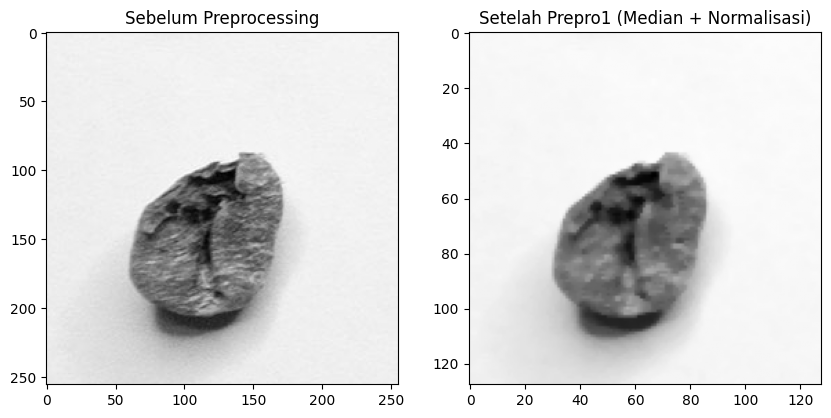

In [44]:
# 1. CEK ANGKA (Pastikan jumlahnya genap 200)
print(f"Jumlah gambar siap ekstrak (dataPreprocessed1) : {len(dataPreprocessed1)}")

# 2. CEK VISUAL (Bandingkan gambar asli vs hasil prepro1)
plt.figure(figsize=(10, 5))

# Gambar Original (Indeks ke-0)
plt.subplot(1, 2, 1)
plt.title("Sebelum Preprocessing")
plt.imshow(data[0], cmap='gray')

# Gambar Hasil Prepro1 (Indeks ke-0)
plt.subplot(1, 2, 2)
plt.title("Setelah Prepro1 (Median + Normalisasi)")
plt.imshow(dataPreprocessed1[0], cmap='gray')

plt.show()

Selesai memproses 200 gambar.
Jumlah gambar siap ekstrak (dataPreprocessed2) : 200


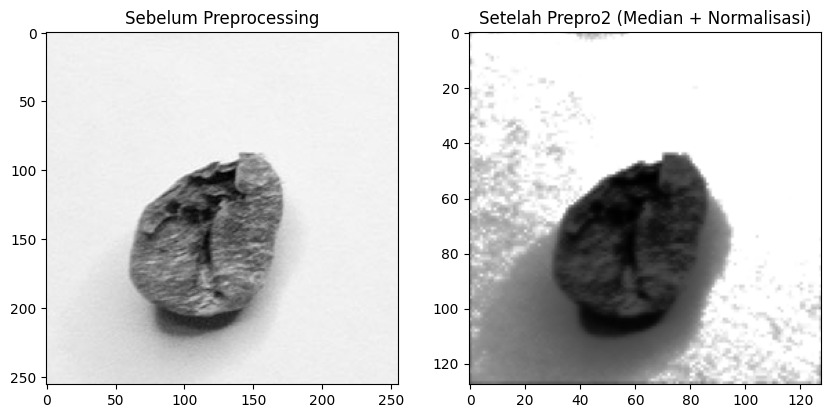

In [45]:
# pada bagian ini bisa gunakan data yang sebelum augmentasi atau setelah augmentasi
dataPreprocessed2 = []
for i in range(len(data)): 
    # 1. Resize dulu pakai fungsi manual
    img_resized = resize(data[i], target_size=(128, 128))
    
    # 2. Panggil eksperimennya (Ganti prepro1 jadi prepro2 / prepro3 untuk tes yang lain)
    img_final = prepro2(img_resized) 
    
    # 3. Masukkan ke list
    dataPreprocessed2.append(img_final)

dataPreprocessed2 = np.array(dataPreprocessed2)
print(f"Selesai memproses {len(dataPreprocessed2)} gambar.")

# 1. CEK ANGKA (Pastikan jumlahnya genap 200)
print(f"Jumlah gambar siap ekstrak (dataPreprocessed2) : {len(dataPreprocessed2)}")

# 2. CEK VISUAL (Bandingkan gambar asli vs hasil prepro2)
plt.figure(figsize=(10, 5))

# Gambar Original (Indeks ke-0)
plt.subplot(1, 2, 1)
plt.title("Sebelum Preprocessing")
plt.imshow(data[0], cmap='gray')

# Gambar Hasil Prepro2 (Indeks ke-0)
plt.subplot(1, 2, 2)
plt.title("Setelah Prepro2 (Median + Normalisasi)")
plt.imshow(dataPreprocessed2[0], cmap='gray')

plt.show()

Selesai memproses 200 gambar.
Jumlah gambar siap ekstrak (dataPreprocessed3) : 200


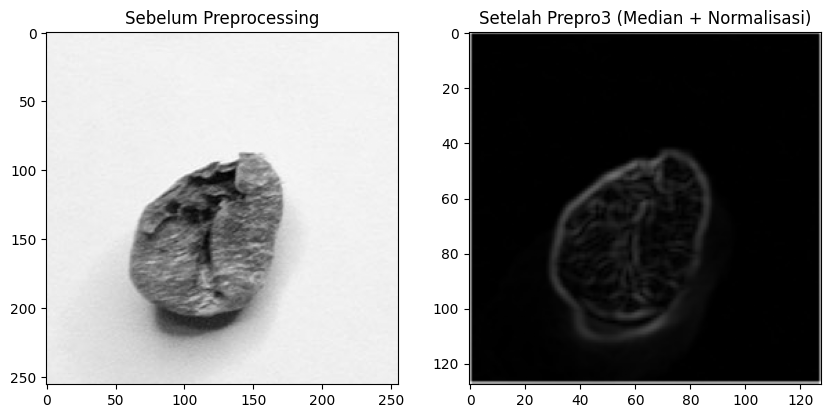

In [46]:
# pada bagian ini bisa gunakan data yang sebelum augmentasi atau setelah augmentasi
dataPreprocessed3 = []
for i in range(len(data)): 
    # 1. Resize dulu pakai fungsi manual
    img_resized = resize(data[i], target_size=(128, 128))
    
    # 2. Panggil eksperimennya (Ganti prepro1 jadi prepro2 / prepro3 untuk tes yang lain)
    img_final = prepro3(img_resized) 
    
    # 3. Masukkan ke list
    dataPreprocessed3.append(img_final)

dataPreprocessed3 = np.array(dataPreprocessed3)
print(f"Selesai memproses {len(dataPreprocessed3)} gambar.")

# 1. CEK ANGKA (Pastikan jumlahnya genap 200)
print(f"Jumlah gambar siap ekstrak (dataPreprocessed3) : {len(dataPreprocessed3)}")

# 2. CEK VISUAL (Bandingkan gambar asli vs hasil prepro3)
plt.figure(figsize=(10, 5))

# Gambar Original (Indeks ke-0)
plt.subplot(1, 2, 1)
plt.title("Sebelum Preprocessing")
plt.imshow(data[0], cmap='gray')

# Gambar Hasil Prepro3 (Indeks ke-0)
plt.subplot(1, 2, 2)
plt.title("Setelah Prepro3 (Median + Normalisasi)")
plt.imshow(dataPreprocessed3[0], cmap='gray')


### Feature Extraction

In [47]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [48]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

In [49]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

In [50]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

In [51]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

In [52]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

In [53]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

In [54]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [55]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [56]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []


In [57]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [58]:
for i in range(len(Derajat0)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [59]:
for i in range(len(Derajat0)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [60]:
for i in range(len(Derajat0)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [61]:
for i in range(len(Derajat0)): 
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [62]:
for i in range(len(Derajat0)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [63]:
for i in range(len(Derajat0)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

### Write the extraction's results to CSV 

In [64]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
# Cek detektif untuk mencari list yang jumlahnya tidak sama
for key, value in dataTable.items():
    print(f"{key}: {len(value)}")


Filename: 200
Label: 200
Contrast0: 200
Contrast45: 200
Contrast90: 200
Contrast135: 200
Homogeneity0: 200
Homogeneity45: 200
Homogeneity90: 200
Homogeneity135: 200
Dissimilarity0: 200
Dissimilarity45: 200
Dissimilarity90: 200
Dissimilarity135: 200
Entropy0: 200
Entropy45: 200
Entropy90: 200
Entropy135: 200
ASM0: 200
ASM45: 200
ASM90: 200
ASM135: 200
Energy0: 200
Energy45: 200
Energy90: 200
Energy135: 200
Correlation0: 200
Correlation45: 200
Correlation90: 200
Correlation135: 200


### Features Selection

pada bagian seleksi fitur ini bisa menggunakan metode seperti
- PCA
- LDA
- t-SNE
- Chi-square
- ANOVA
- Autoencoder
- correlation
- dll

berikut contoh menggunakan correlation:

In [65]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

NameError: name 'hasilEkstrak' is not defined

## Splitting Data

In [ ]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

## Feature Normalization

berikut metode normalisasi yang bisa digunakan:
- Min-Max Scaling
- Standardization (Z-score)
- Robust Scaling
- MaxAbsScaler
- dll

berikut contoh menggunakan Standardization (Z-score):

In [ ]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling

### Define Model

In [ ]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

In [ ]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

### Train SVM Classifier

In [ ]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)

### Train KNN Classifier

In [ ]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


## Evaluation With Confusion Matrix

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")